In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nakulhemantkarpe/processed-nashik-aqi-data/processed_aqi_data.csv


# Model Training

**Now,the data has been analyzed, processed features have been extracted, now we feed this data to train various ML and DL models**

Models we will train:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. XGBoost Regressor
5. Support Vector Regressor (SVR)
6. K-Nearest Neighbors Regressor (KNN Regressor)
7. Artificial Neural Network (ANN)
   

First, let us import the processed data file 
-

In [17]:
df=pd.read_csv("/kaggle/input/datasets/nakulhemantkarpe/processed-nashik-aqi-data/processed_aqi_data.csv")

In [18]:
df

,No. Stations,Air Quality,Index Value,year,day,month,weekdays,month_sin,month_cos,AQI_lag_1,...,"Prominent Pollutant_CO, PM10","Prominent Pollutant_CO, PM2.5",Prominent Pollutant_NO2,Prominent Pollutant_O3,"Prominent Pollutant_O3, PM10","Prominent Pollutant_O3, PM2.5",Prominent Pollutant_OZONE,Prominent Pollutant_PM10,"Prominent Pollutant_PM10, PM2.5",Prominent Pollutant_PM2.5
0,1.0,Good,39,2016,29,5,6,5.000000e-01,-0.866025,45.0,...,False,False,False,False,False,False,False,True,False,False
1,1.0,Good,36,2016,30,5,0,5.000000e-01,-0.866025,39.0,...,False,False,False,True,False,False,False,False,False,False
2,1.0,Good,47,2016,1,6,2,1.224647e-16,-1.000000,36.0,...,False,False,False,False,False,False,False,True,False,False
3,1.0,Satisfactory,52,2016,2,6,3,1.224647e-16,-1.000000,47.0,...,False,False,False,False,False,False,False,True,False,False
4,1.0,Satisfactory,57,2016,3,6,4,1.224647e-16,-1.000000,52.0,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2400,4.0,Moderate,197,2023,27,12,2,-2.449294e-16,1.000000,188.0,...,False,False,False,False,False,False,False,False,False,True
2401,3.0,Moderate,199,2023,28,12,3,-2.449294e-16,1.000000,197.0,...,False,False,False,False,False,False,False,False,False,True
2402,4.0,Moderate,154,2023,29,12,4,-2.449294e-16,1.000000,199.0,...,False,False,False,False,False,False,False,False,False,True
2403,4.0,Moderate,170,2023,30,12,5,-2.449294e-16,1.000000,154.0,...,False,False,False,False,False,False,False,False,False,True


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.neighbors import KNeighborsRegressor

Lets declare depenedent and independent variables and do the train test split
-

In [20]:
X=df.drop(['Index Value','Air Quality'], axis =1)
y=df['Index Value']

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

We will create a piepline to train and make predictions for all these models
-

**here only decision tree randomforest and xgboost needs random state because others are detetministic**

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
Pipelines={
    "Linear Regression":Pipeline([("scaler",StandardScaler()), ('model',LinearRegression())]),
    
    "Decision Tree ":Pipeline([("model",DecisionTreeRegressor(random_state=42))]),
    
    "Random Forest":Pipeline([('model',RandomForestRegressor(random_state=42))]),
    
    "SVR":Pipeline([('scaler',StandardScaler()),('model',SVR())]),
    
    "XG Boost":Pipeline([('model',xgb.XGBRegressor(random_state=42))]),
    
    "KNN":Pipeline([('scaler',StandardScaler()),('model',KNeighborsRegressor())])

    }

for name,Pipeline in Pipelines.items():
    Pipeline.fit(X_train,y_train)
    y_pred=Pipeline.predict(X_test)

    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))


Linear Regression
MAE: 19.159492092579427
RMSE: 28.738330362347845
R2 Score: 0.7604902079289997

Decision Tree 
MAE: 29.41787941787942
RMSE: 44.883448046288834
R2 Score: 0.4157850936506431

Random Forest
MAE: 19.94226611226611
RMSE: 30.12952767711001
R2 Score: 0.7367400133232891

SVR
MAE: 24.19680934057474
RMSE: 35.82217775138512
R2 Score: 0.6278618648444507

XG Boost
MAE: 20.20657730102539
RMSE: 30.218397546742427
R2 Score: 0.7351846694946289

KNN
MAE: 20.57920997920998
RMSE: 30.96060806184613
R2 Score: 0.7220164024807594



so far, **Linear Regression** performed the best because our features made data mostly linear, espeically lag function helped a lot
---

**we will do hyperparameter tuning to see if any other model outperforms linear regression**

In [23]:
from sklearn.pipeline import Pipeline

rf = Pipeline([ ("model", RandomForestRegressor(  n_estimators=200,max_depth=10, random_state=42))])
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 19.77520060823156
RMSE: 30.108816044370922
R2: 0.7371018291555221


In [24]:
xgb_model = Pipeline([ ("model", xgb.XGBRegressor
                        (  n_estimators=1000, learning_rate=0.01, max_depth=3,
                         min_child_weight=1, gamma=0,subsample=0.9,colsample_bytree=0.9,reg_alpha=0,
                         reg_lambda=1,random_state=42))])
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 18.876323699951172
RMSE: 28.76554012752281
R2: 0.7600364685058594


In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Dropout

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [38]:
model=Sequential([
    Dense(128,activation='relu'),
    Dropout(0.2),
    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(1)
])

(<Dense name=dense_3, built=False>,)

In [28]:
model.compile(  optimizer="adam", loss="mse", metrics=["mse", "mae"])

In [29]:
model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 10596.1826 - mae: 86.6096 - mse: 10596.1826 - val_loss: 9965.1328 - val_mae: 83.6385 - val_mse: 9965.1328
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6451.2261 - mae: 63.1967 - mse: 6451.2261 - val_loss: 3292.4243 - val_mae: 43.8223 - val_mse: 3292.4243
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1565.7521 - mae: 27.8963 - mse: 1565.7521 - val_loss: 1113.8669 - val_mae: 23.3489 - val_mse: 1113.8669
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1031.5844 - mae: 22.8648 - mse: 1031.5844 - val_loss: 1013.0063 - val_mae: 21.7822 - val_mse: 1013.0063
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 985.5118 - mae: 21.8420 - mse: 985.5118 - val_loss: 969.7207 - val_mae: 20.9460 - val_mse: 969.7207
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 982.4965 - mae: 22.1091 - mse: 982.4965 - val_loss: 950.4048 - val_mae: 20.4539 - val_mse: 950.4048
Epoch 7/100
49/49 ━━━━━━━━━━

In [30]:
y_pred = model.predict(X_test_scaled).flatten()


print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
MAE: 18.650524139404297
RMSE: 28.41748952559849
R2: 0.7658082246780396


In [31]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["ANN", "Linear Regression", "Tuned XGBoost", "Tuned RF", "Random Forest", "XGBoost", "KNN", "SVR", "Decision Tree"],
    "MAE": [18.8214, 19.1595, 18.8763, 19.7752, 19.9423, 20.2066, 20.5792, 24.1968, 29.4179],
    "RMSE": [28.3949, 28.7383, 28.7655, 30.1088, 30.1295, 30.2184, 30.9606, 35.8222, 44.8834],
    "R2 Score": [0.7662, 0.7605, 0.7600, 0.7371, 0.7367, 0.7352, 0.7220, 0.6279, 0.4158]
})

print(results)

               Model      MAE     RMSE  R2 Score
0                ANN  18.8214  28.3949    0.7662
1  Linear Regression  19.1595  28.7383    0.7605
2      Tuned XGBoost  18.8763  28.7655    0.7600
3           Tuned RF  19.7752  30.1088    0.7371
4      Random Forest  19.9423  30.1295    0.7367
5            XGBoost  20.2066  30.2184    0.7352
6                KNN  20.5792  30.9606    0.7220
7                SVR  24.1968  35.8222    0.6279
8      Decision Tree  29.4179  44.8834    0.4158


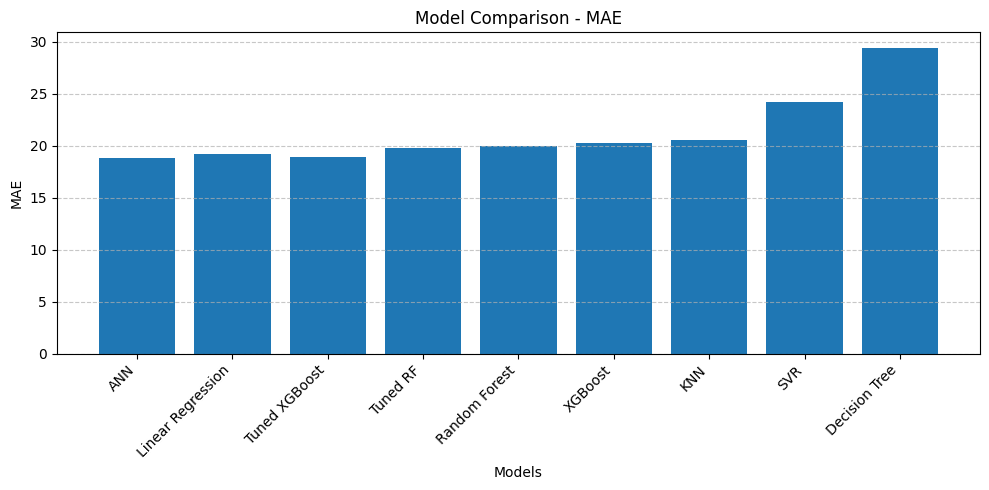

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["MAE"])
plt.title("Model Comparison - MAE")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

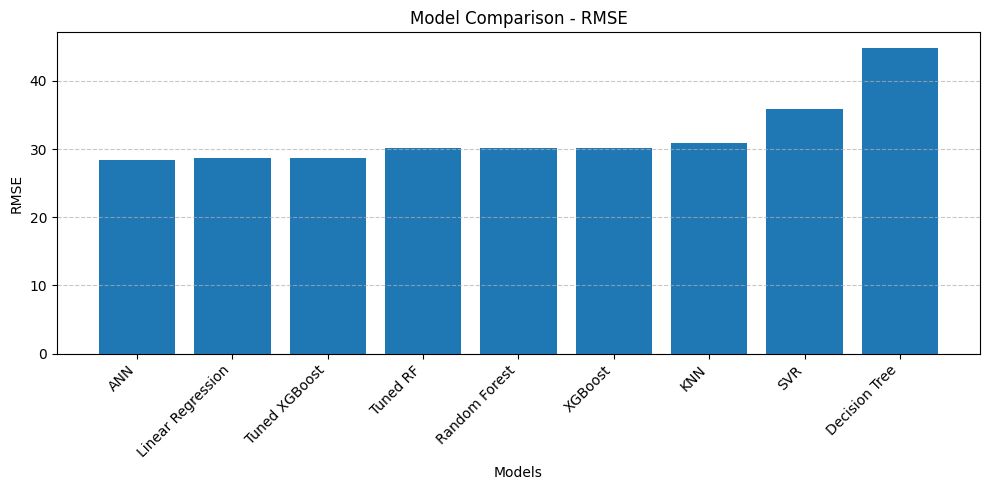

In [33]:
plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["RMSE"])
plt.title("Model Comparison - RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

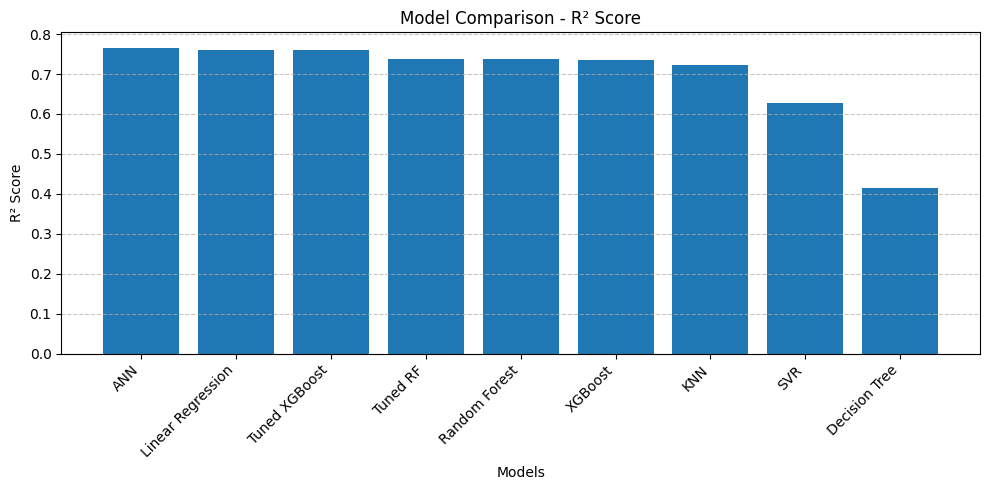

In [34]:

plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["R2 Score"])
plt.title("Model Comparison - R² Score")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [44]:
sample = X_test.iloc[[0]]
print("Actual AQI:", y_test.iloc[0])

for name, pipeline in Pipelines.items():
    print(f"{name}: {pipeline.predict(sample)[0]:.2f}")

print("Tuned Random Forest:", rf.predict(sample)[0])
print("Tuned XGBoost:", xgb_model.predict(sample)[0])

sample_scaled = scaler.transform(sample)
print("ANN:", model.predict(sample_scaled, verbose=0)[0][0])

Actual AQI: 60
Linear Regression: 50.77
Decision Tree : 67.00
Random Forest: 58.06
SVR: 56.15
XG Boost: 57.41
KNN: 58.00
Tuned Random Forest: 58.283466804553775
Tuned XGBoost: 57.80047
ANN: 53.73105


 **Conclusion** 
* ANN achieved the best overall performance among all the models.
* It recorded the lowest MAE and RMSE, indicating the smallest prediction errors.
* It obtained the highest R² score (0.7662), explaining about 76.6% of the variation in AQI.
* Linear Regression was the best-performing traditional machine learning model.
* Hyperparameter tuning improved the performance of Random Forest and XGBoost, but they did not      surpass the ANN.
* The engineered features helped all models learn AQI patterns effectively.
* Therefore, the ANN was selected as the final model for AQI prediction due to its superior accuracy   and overall performance.

In [36]:
model.save("aqi_prediction_ann.keras")

In [37]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

now, next step is to make a **Streamlit Dashboard!**